In [1]:
from google.colab import files
uploaded = files.upload()


Saving fer2013_images.zip.zip to fer2013_images.zip.zip


In [3]:
import zipfile
import os

with zipfile.ZipFile("fer2013_images.zip.zip", 'r') as zip_ref:
    zip_ref.extractall()

os.listdir()

['.config', 'train', 'test', 'fer2013_images.zip.zip', 'sample_data']

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = 'train'
test_dir = 'test'

img_height, img_width = 48, 48
batch_size = 64

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.fit(train_generator, epochs=20, validation_data=test_generator)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2511 - loss: 1.7936

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.2513 - loss: 1.7933 - val_accuracy: 0.3979 - val_loss: 1.5437
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4091 - loss: 1.5233 - val_accuracy: 0.4765 - val_loss: 1.3814
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.4582 - loss: 1.4113 - val_accuracy: 0.4983 - val_loss: 1.3052
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4971 - loss: 1.3222 - val_accuracy: 0.5189 - val_loss: 1.2507
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5128 - loss: 1.2758 - val_accuracy: 0.5248 - val_loss: 1.2382
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.5372 - loss: 1.2209 - val_accuracy: 0.5378 - val_loss: 1.2200
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5525 - loss: 1.1804 - val_accuracy: 0.5449 - val_loss: 1.1845
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.5728 - loss: 1.1324 - val_accurac

In [7]:
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc*100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5458 - loss: 1.2809
Test Accuracy: 57.26%


In [8]:
import numpy as np
class_indices = train_generator.class_indices
# Mapping index to class name
labels = dict((v,k) for k,v in class_indices.items())

# Predict on few test images
test_generator.reset()  # Ensure correct ordering

# Get batch of test images
x_test, y_test = next(test_generator)

# Predict
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Print results
for i in range(5):  # Show first 5 examples
    print(f"True Label: {labels[true_classes[i]]}, Predicted: {labels[predicted_classes[i]]}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step 
True Label: angry, Predicted: angry
True Label: angry, Predicted: angry
True Label: angry, Predicted: sad
True Label: angry, Predicted: angry
True Label: angry, Predicted: angry


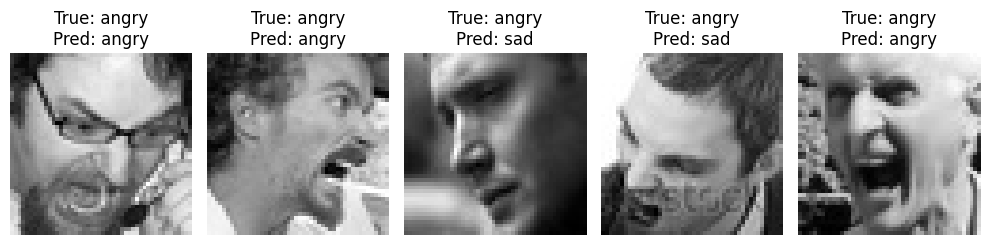

In [13]:
import matplotlib.pyplot as plt

# Show first 5 test images with labels
plt.figure(figsize=(10, 10))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = x_test[i].reshape(48, 48)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {labels[true_classes[i]]}\nPred: {labels[predicted_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()